# Predictive Air Quality Modeling
### ARIMA vs. LSTM Forecasting with Apriori Pattern Mining on the UCI Air Quality Dataset

This notebook builds a hybrid forecasting and pattern-mining pipeline for hourly urban air pollution data. It compares a classical statistical model (**ARIMA**) against a deep learning model (**LSTM**) for forecasting CO concentration, and uses **Apriori** association rule mining to uncover co-occurrence patterns between high pollutant levels and seasonal/temporal conditions.

**Dataset:** [UCI Air Quality Dataset](https://archive.ics.uci.edu/dataset/360/air+quality) — 9,357 hourly readings (March 2004 – February 2005) from a multisensor device in an Italian city.

**Pipeline overview:**
1. Data loading & exploratory analysis
2. Cleaning & preprocessing (sentinel handling, outlier capping, scaling, lag features)
3. ARIMA forecasting
4. LSTM forecasting
5. Apriori association rule mining
6. Model comparison & summary dashboard


In [150]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels tensorflow keras mlxtend

(installation output omitted for brevity)


In [151]:
pip install ucimlrepo

(installation output omitted for brevity)


## 1. Data Loading

Fetch the dataset directly from the UCI ML Repository.


In [152]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features
y = air_quality.data.targets

# metadata
print(air_quality.metadata)

# variable information
print(air_quality.variables)


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [153]:
import pandas as pd

# 1. Load the dataset into a DataFrame
# The dataset was already fetched in a previous cell as 'air_quality.data.features' (X)
df = X.copy() # Use the already loaded features DataFrame

# 2. Check shape, column names, and data types
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

# 3. Print basic statistics
display(df.describe())

Dataset Shape: (9357, 15)

Column Names: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data Types:
 Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

print("All libraries imported successfully")

All libraries imported successfully


In [155]:
# If using Google Colab, upload the file first using this:
from google.colab import files
uploaded = files.upload()  # select AirQualityUCI.csv or .xlsx

# Load the dataset
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# Preview first 5 rows
df.head()


Saving AirQualityUCI.csv to AirQualityUCI (2).csv
Saving AirQualityUCI.xlsx to AirQualityUCI (2).xlsx


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 2. Exploratory Data Analysis

Inspect shape, missing values, and visualize raw pollutant trends before cleaning.


In [156]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (9471, 17)

Column Names:
 ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Data Types:
 Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

Basic Statistics:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


In [157]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print(missing_df[missing_df['Missing Count'] > 0])

Missing values per column:
               Missing Count  Missing %
Date                     114        1.2
Time                     114        1.2
CO(GT)                   114        1.2
PT08.S1(CO)              114        1.2
NMHC(GT)                 114        1.2
C6H6(GT)                 114        1.2
PT08.S2(NMHC)            114        1.2
NOx(GT)                  114        1.2
PT08.S3(NOx)             114        1.2
NO2(GT)                  114        1.2
PT08.S4(NO2)             114        1.2
PT08.S5(O3)              114        1.2
T                        114        1.2
RH                       114        1.2
AH                       114        1.2
Unnamed: 15             9471      100.0
Unnamed: 16             9471      100.0


In [158]:
# Combine Date and Time into one datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                 format='%d/%m/%Y %H.%M.%S',
                                 errors='coerce')

# Drop rows where datetime could not be parsed
df = df.dropna(subset=['Datetime'])

# Set as index
df = df.set_index('Datetime')

# Drop the original Date and Time columns
df = df.drop(columns=['Date', 'Time'], errors='ignore')

print("Datetime index set successfully")
print("New shape:", df.shape)
df.head()


Datetime index set successfully
New shape: (9357, 15)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
Datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 3. Data Cleaning & Preprocessing

The UCI dataset uses `-200` as a sentinel value for missing/faulty sensor readings. We convert these to `NaN`, impute, cap outliers with the IQR method, rescale with `MinMaxScaler`, and engineer 24-hour lag features for modeling.


In [159]:
# UCI dataset uses -200 as a sensor error / missing value marker
# Replace all -200 values with NaN so we can handle them properly

df.replace(-200, np.nan, inplace=True)

print("Sentinel values (-200) replaced with NaN")
print("\nMissing values after replacement:")
print(df.isnull().sum())

Sentinel values (-200) replaced with NaN

Missing values after replacement:
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Unnamed: 15      9357
Unnamed: 16      9357
dtype: int64


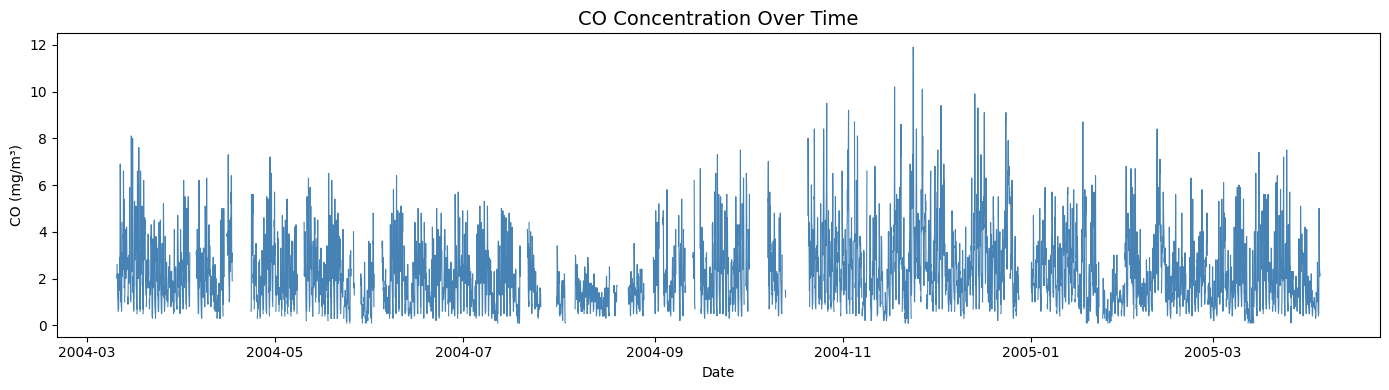

Plot saved as co_timeseries.png


In [160]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['CO(GT)'], color='steelblue', linewidth=0.8)
plt.title('CO Concentration Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('CO (mg/m³)')
plt.tight_layout()
plt.savefig('co_timeseries.png', dpi=150)
plt.show()
print("Plot saved as co_timeseries.png")

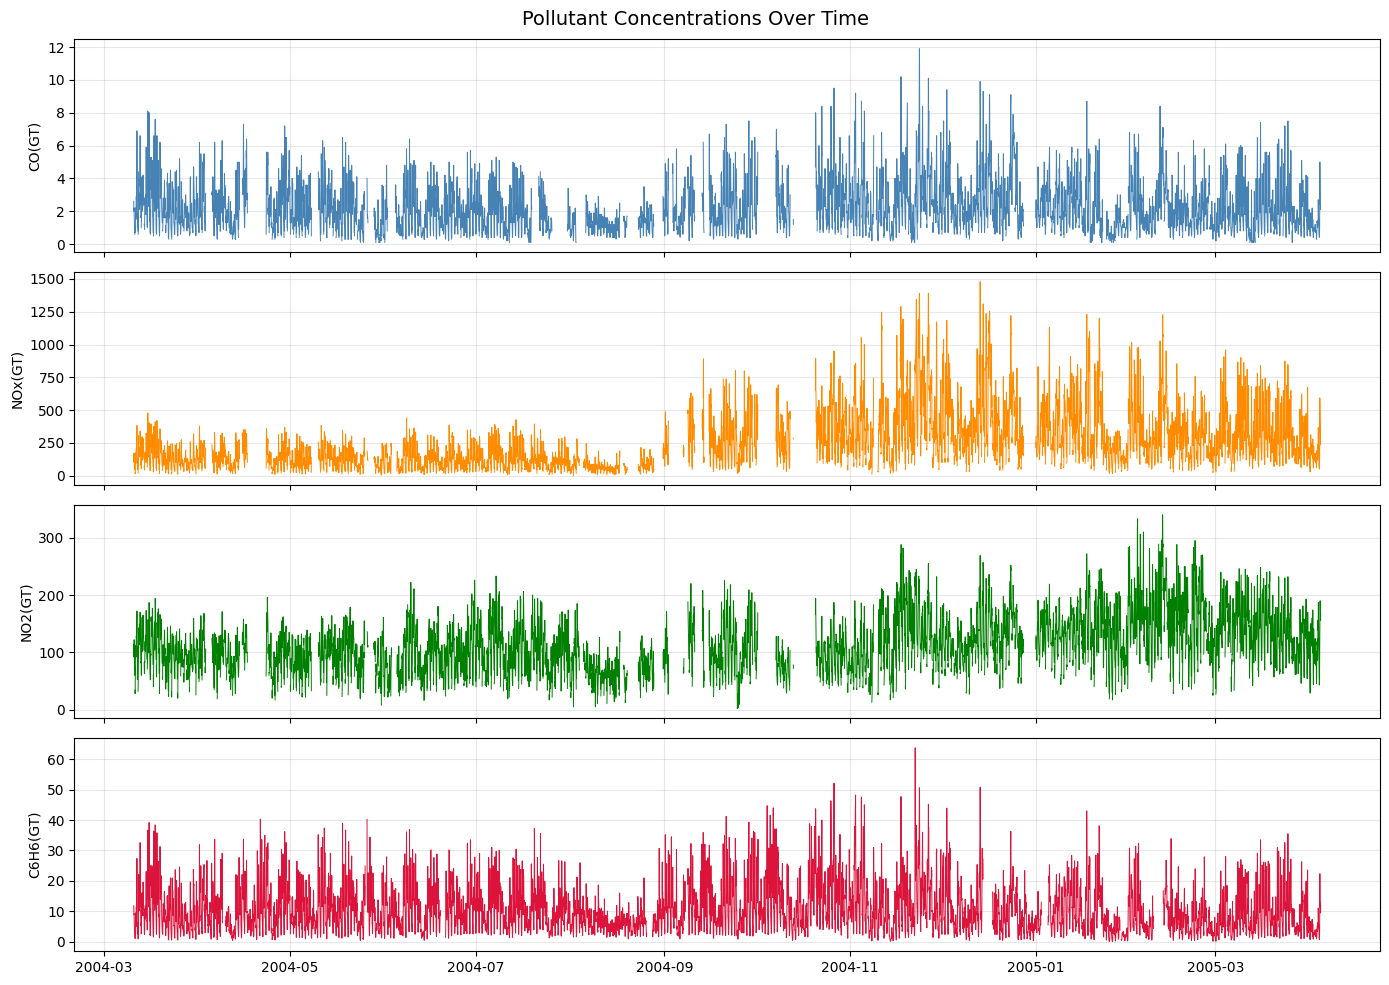

In [161]:
pollutants = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

colors = ['steelblue', 'darkorange', 'green', 'crimson']

for i, col in enumerate(pollutants):
    if col in df.columns:
        axes[i].plot(df.index, df[col], color=colors[i], linewidth=0.7)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Pollutant Concentrations Over Time', fontsize=14)
plt.tight_layout()
plt.savefig('all_pollutants.png', dpi=150)
plt.show()

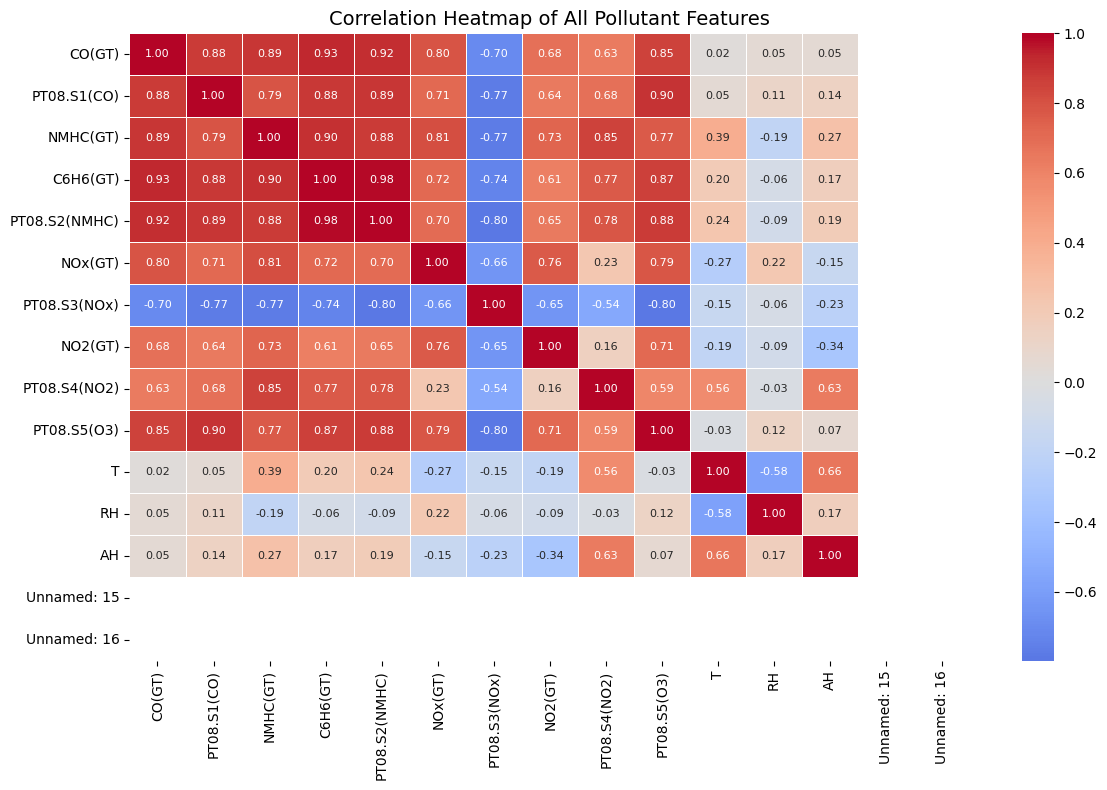

In [162]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Heatmap of All Pollutant Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

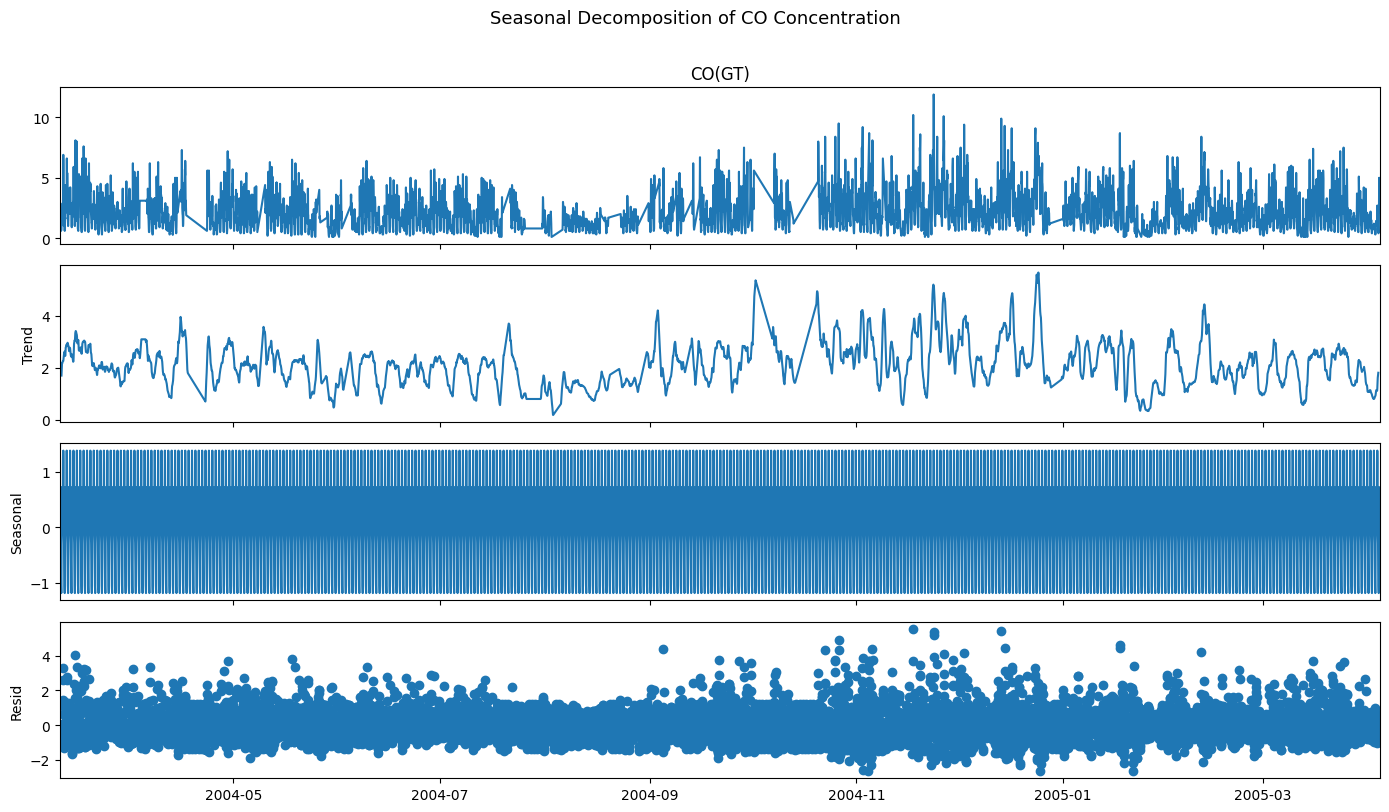

In [163]:
# Use CO(GT) column, drop NaN for decomposition
co_series = df['CO(GT)'].dropna()

# Resample to hourly to ensure regular frequency
co_hourly = co_series.resample('H').mean().interpolate()

decomposition = seasonal_decompose(co_hourly,
                                    model='additive',
                                    period=24)  # 24 = daily cycle

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Seasonal Decomposition of CO Concentration', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=150)
plt.show()

In [164]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total records     : {df.shape[0]}")
print(f"Total features    : {df.shape[1]}")
print(f"Date range        : {df.index.min()} to {df.index.max()}")
print(f"Target variable   : CO(GT) — Carbon Monoxide concentration")
print(f"Missing values    : {df.isnull().sum().sum()} total across all columns")
print("=" * 50)

DATASET SUMMARY — USE IN YOUR REPORT
Total records     : 9357
Total features    : 15
Date range        : 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Target variable   : CO(GT) — Carbon Monoxide concentration
Missing values    : 35415 total across all columns


In [165]:
# UCI dataset has 2 unnamed empty columns at the end
# Drop any column that is more than 50% missing

threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

print("Columns after dropping empty ones:")
print(df.columns.tolist())
print("Shape:", df.shape)

Columns after dropping empty ones:
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Shape: (9357, 12)


In [166]:
# Some columns may have loaded as object/string type
# Force convert all to numeric, errors become NaN

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


In [167]:
# Step 1 — Forward fill (use previous hour's value)
df = df.fillna(method='ffill')

# Step 2 — Backward fill (catch any remaining at start)
df = df.fillna(method='bfill')

# Step 3 — Verify no missing values remain
print("Missing values after handling:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values after handling:
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Total missing: 0


In [168]:
# Define your target variable and input features
target = 'CO(GT)'

# Select relevant pollutant columns as features
feature_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']

# Keep only columns that actually exist in your dataframe
feature_cols = [col for col in feature_cols if col in df.columns]

print("Features selected:", feature_cols)
print("Target variable :", target)

# Create a clean working dataframe
data = df[feature_cols].copy()
data.head()

Features selected: ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
Target variable : CO(GT)


,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
Datetime,,,,,,,
2004-03-10 18:00:00,2.6,166.0,113.0,11.9,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,103.0,92.0,9.4,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,131.0,114.0,9.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,172.0,122.0,9.2,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,131.0,116.0,6.5,11.2,59.6,0.7888


In [169]:
# Ensure the time series has a clean hourly frequency
# This is required for ARIMA and LSTM

data = data.resample('H').mean()
data = data.interpolate(method='time')

print("Shape after resampling:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())
data.head()

Shape after resampling: (9357, 7)
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00


,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
Datetime,,,,,,,
2004-03-10 18:00:00,2.6,166.0,113.0,11.9,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,103.0,92.0,9.4,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,131.0,114.0,9.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,172.0,122.0,9.2,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,131.0,116.0,6.5,11.2,59.6,0.7888


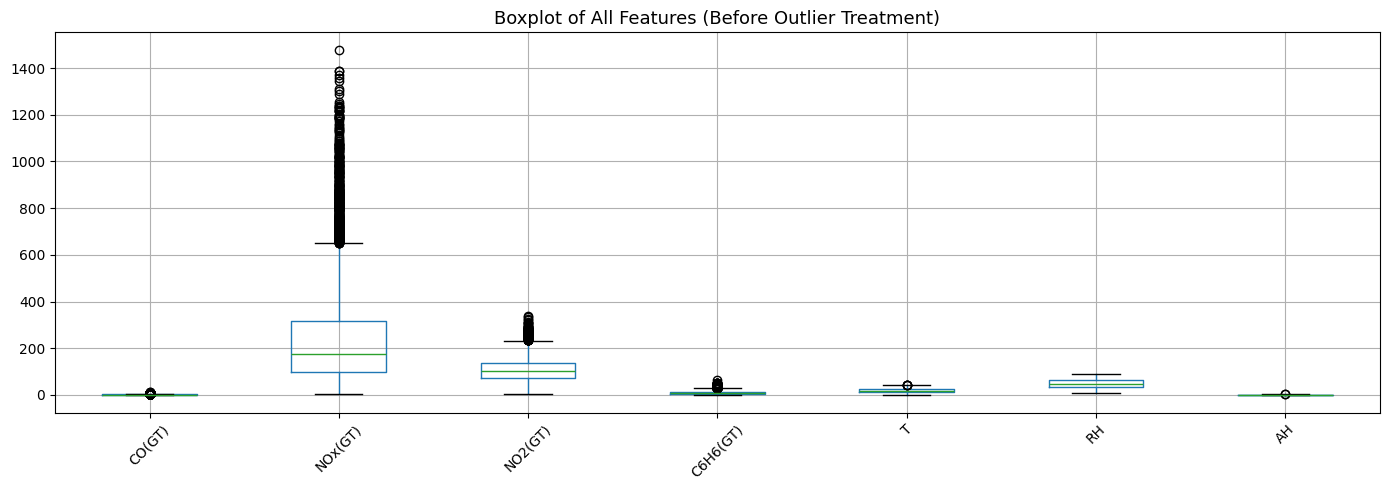

Outliers capped using IQR method


In [170]:
# Plot boxplots to visually identify outliers
plt.figure(figsize=(14, 5))
data.boxplot()
plt.title('Boxplot of All Features (Before Outlier Treatment)', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=150)
plt.show()

# Cap outliers using IQR method
def cap_outliers(df):
    df_capped = df.copy()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df[col].clip(lower=lower, upper=upper)
    return df_capped

data = cap_outliers(data)
print("Outliers capped using IQR method")

In [171]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform
scaled_values = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_values,
                          columns=data.columns,
                          index=data.index)

print("Data normalised to range [0, 1]")
print("\nSample of scaled data:")
scaled_df.head()

Data normalised to range [0, 1]

Sample of scaled data:


,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
Datetime,,,,,,,
2004-03-10 18:00:00,0.462963,0.253282,0.480519,0.416961,0.345982,0.499371,0.287593
2004-03-10 19:00:00,0.351852,0.155985,0.389610,0.328622,0.339286,0.484277,0.271384
2004-03-10 20:00:00,0.388889,0.199228,0.484848,0.314488,0.308036,0.563522,0.283779
2004-03-10 21:00:00,0.388889,0.262548,0.519481,0.321555,0.287946,0.638994,0.302095
2004-03-10 22:00:00,0.277778,0.199228,0.493506,0.226148,0.292411,0.633962,0.303149


In [172]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


In [173]:
# Lag features help the model learn from past values
# t-1 = 1 hour ago, t-2 = 2 hours ago, t-24 = same hour yesterday

target_col = 'CO(GT)'

for lag in [1, 2, 3, 24]:
    scaled_df[f'{target_col}_lag{lag}'] = scaled_df[target_col].shift(lag)

# Drop rows with NaN created by shifting
scaled_df = scaled_df.dropna()

print("Lag features created:")
print([col for col in scaled_df.columns if 'lag' in col])
print("\nNew shape:", scaled_df.shape)

Lag features created:
['CO(GT)_lag1', 'CO(GT)_lag2', 'CO(GT)_lag3', 'CO(GT)_lag24']

New shape: (9333, 11)


## 4. ARIMA Modeling

We test stationarity with the Augmented Dickey-Fuller test, select `(p, q)` via AIC grid search, fit ARIMA, and evaluate on the held-out test set.


In [174]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data[target].dropna())

print("=" * 45)
print("Augmented Dickey-Fuller Test Results")
print("=" * 45)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n✅ Series is STATIONARY (p < 0.05)")
    print("No differencing needed for ARIMA")
else:
    print("\n⚠️ Series is NON-STATIONARY (p > 0.05)")
    print("Use d=1 in ARIMA for differencing")

Augmented Dickey-Fuller Test Results
ADF Statistic : -9.2735
p-value       : 0.0000
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

✅ Series is STATIONARY (p < 0.05)
No differencing needed for ARIMA


In [175]:
# Chronological split — NEVER use random split for time series
split_ratio = 0.80
split_index = int(len(scaled_df) * split_ratio)

train_df = scaled_df.iloc[:split_index]
test_df  = scaled_df.iloc[split_index:]

print("=" * 40)
print("Train/Test Split Summary")
print("=" * 40)
print(f"Total samples : {len(scaled_df)}")
print(f"Training set  : {len(train_df)} rows ({split_ratio*100:.0f}%)")
print(f"Test set      : {len(test_df)} rows ({(1-split_ratio)*100:.0f}%)")
print(f"Train period  : {train_df.index.min()} → {train_df.index.max()}")
print(f"Test period   : {test_df.index.min()} → {test_df.index.max()}")

Train/Test Split Summary
Total samples : 9333
Training set  : 7466 rows (80%)
Test set      : 1867 rows (20%)
Train period  : 2004-03-11 18:00:00 → 2005-01-16 19:00:00
Test period   : 2005-01-16 20:00:00 → 2005-04-04 14:00:00


In [176]:
# Separate features (X) and target (y) for both sets
target_col = 'CO(GT)'

X_train = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_test  = test_df.drop(columns=[target_col]).values
y_test  = test_df[target_col].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (7466, 10)
y_train shape: (7466,)
X_test shape : (1867, 10)
y_test shape : (1867,)


In [177]:
# LSTM requires 3D input: [samples, timesteps, features]
# We use a sliding window of 24 hours (lookback)

def create_sequences(X, y, lookback=24):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

LOOKBACK = 24

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  LOOKBACK)

print("LSTM Input Shapes:")
print("X_train_seq:", X_train_seq.shape)  # (samples, 24, features)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)

LSTM Input Shapes:
X_train_seq: (7442, 24, 10)
y_train_seq: (7442,)
X_test_seq : (1843, 24, 10)
y_test_seq : (1843,)


In [178]:
import joblib

# Save everything needed for modelling phases
joblib.dump(X_train_seq, 'X_train_seq.pkl')
joblib.dump(y_train_seq, 'y_train_seq.pkl')
joblib.dump(X_test_seq,  'X_test_seq.pkl')
joblib.dump(y_test_seq,  'y_test_seq.pkl')
joblib.dump(train_df[target_col].values, 'y_train_raw.pkl')
joblib.dump(test_df[target_col].values,  'y_test_raw.pkl')

print("All preprocessed arrays saved successfully")

All preprocessed arrays saved successfully


In [179]:
# LSTM requires 3D input: [samples, timesteps, features]
# We use a sliding window of 24 hours (lookback)

def create_sequences(X, y, lookback=24):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

LOOKBACK = 24

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  LOOKBACK)

print("LSTM Input Shapes:")
print("X_train_seq:", X_train_seq.shape)  # (samples, 24, features)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)

LSTM Input Shapes:
X_train_seq: (7442, 24, 10)
y_train_seq: (7442,)
X_test_seq : (1843, 24, 10)
y_test_seq : (1843,)


In [180]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("ARIMA libraries imported successfully")

ARIMA libraries imported successfully


In [181]:
# ARIMA works on a single variable (univariate)
# We use the original unscaled CO(GT) column for interpretability

target_col = 'CO(GT)'

# Use the clean resampled data from Phase 3
arima_series = data[target_col].copy()

# Split same as before — 80% train, 20% test
split_index = int(len(arima_series) * 0.80)

train_arima = arima_series.iloc[:split_index]
test_arima  = arima_series.iloc[split_index:]

print("ARIMA Series Summary")
print("=" * 40)
print(f"Total length : {len(arima_series)}")
print(f"Training set : {len(train_arima)} rows")
print(f"Test set     : {len(test_arima)} rows")
print(f"Train mean   : {train_arima.mean():.4f}")
print(f"Test mean    : {test_arima.mean():.4f}")

ARIMA Series Summary
Total length : 9357
Training set : 7485 rows
Test set     : 1872 rows
Train mean   : 2.0900
Test mean    : 1.8778


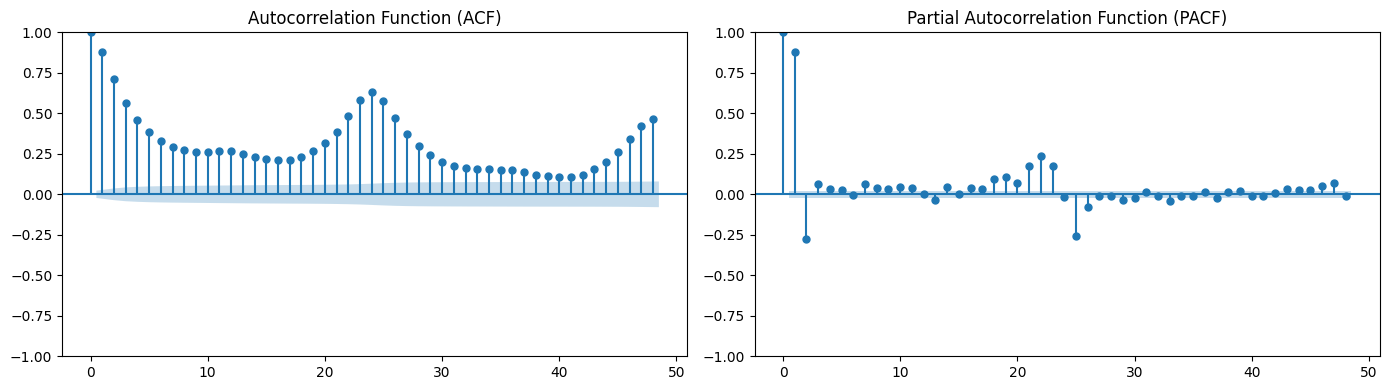

ACF/PACF plots saved as acf_pacf.png


In [182]:
# ACF and PACF plots help you choose p and q values for ARIMA(p,d,q)
# ACF  → tells you q (MA order)
# PACF → tells you p (AR order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train_arima.dropna(), lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12)

plot_pacf(train_arima.dropna(), lags=48, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12)

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

print("ACF/PACF plots saved as acf_pacf.png")

In [183]:
# Try different combinations of p and q
# Lower AIC = better model fit

import itertools

p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

best_aic = np.inf
best_order = None
results_list = []

print("Testing ARIMA parameter combinations...")
print("=" * 45)

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train_arima, order=(p, d, q))
        result = model.fit()
        aic = result.aic
        results_list.append({'p': p, 'd': d, 'q': q, 'AIC': round(aic, 2)})
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA Order : {best_order}")
print(f"Best AIC Score   : {best_aic:.2f}")

# Show top 5 combinations
results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("\nTop 10 ARIMA combinations:")
print(results_df.to_string(index=False))

Testing ARIMA parameter combinations...
Best ARIMA Order : (3, 0, 3)
Best AIC Score   : 14007.31

Top 10 ARIMA combinations:
 p  d  q      AIC
 3  0  3 14007.31
 2  1  3 14077.43
 3  0  1 14080.54
 3  0  2 14080.72
 2  0  3 14092.03
 3  1  2 14102.18
 2  1  2 14102.48
 3  1  1 14102.68
 2  1  1 14103.29
 3  1  3 14104.18


In [184]:
# Fit the best model found above
print(f"Fitting ARIMA{best_order} model...")

arima_model = ARIMA(train_arima, order=best_order)
arima_result = arima_model.fit()

# Print model summary
print(arima_result.summary())

Fitting ARIMA(3, 0, 3) model...
                               SARIMAX Results                                
Dep. Variable:                 CO(GT)   No. Observations:                 7485
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -6995.654
Date:                Mon, 08 Jun 2026   AIC                          14007.308
Time:                        09:48:23   BIC                          14062.673
Sample:                    03-10-2004   HQIC                         14026.322
                         - 01-16-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0973      0.128     16.401      0.000       1.847       2.348
ar.L1          2.7072      0.012    220.615      0.000       2.683       2.731
ar.L2         -2.477

In [185]:
# Forecast for the length of the test set
n_forecast = len(test_arima)

forecast = arima_result.forecast(steps=n_forecast)
forecast.index = test_arima.index

print(f"Forecast generated for {n_forecast} steps")
print("\nFirst 5 predicted values:")
print(forecast.head())

Forecast generated for 1872 steps

First 5 predicted values:
Datetime
2005-01-16 15:00:00    1.101347
2005-01-16 16:00:00    1.516287
2005-01-16 17:00:00    1.841678
2005-01-16 18:00:00    2.079133
2005-01-16 19:00:00    2.234771
Freq: h, Name: predicted_mean, dtype: float64


In [186]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
rmse = np.sqrt(mean_squared_error(test_arima, forecast))
mae  = mean_absolute_error(test_arima, forecast)
mape = np.mean(np.abs((test_arima - forecast) / test_arima)) * 100
r2   = r2_score(test_arima, forecast)

print("=" * 40)
print("ARIMA Model Evaluation Results")
print("=" * 40)
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"R²    : {r2:.4f}")
print("=" * 40)

# Save metrics for comparison in Phase 7
arima_metrics = {
    'Model': 'ARIMA',
    'RMSE' : round(rmse, 4),
    'MAE'  : round(mae, 4),
    'MAPE' : round(mape, 2),
    'R2'   : round(r2, 4)
}

print("\n✅ Metrics saved for model comparison")

ARIMA Model Evaluation Results
RMSE  : 1.3255
MAE   : 1.0877
MAPE  : 138.39%
R²    : -0.0338

✅ Metrics saved for model comparison


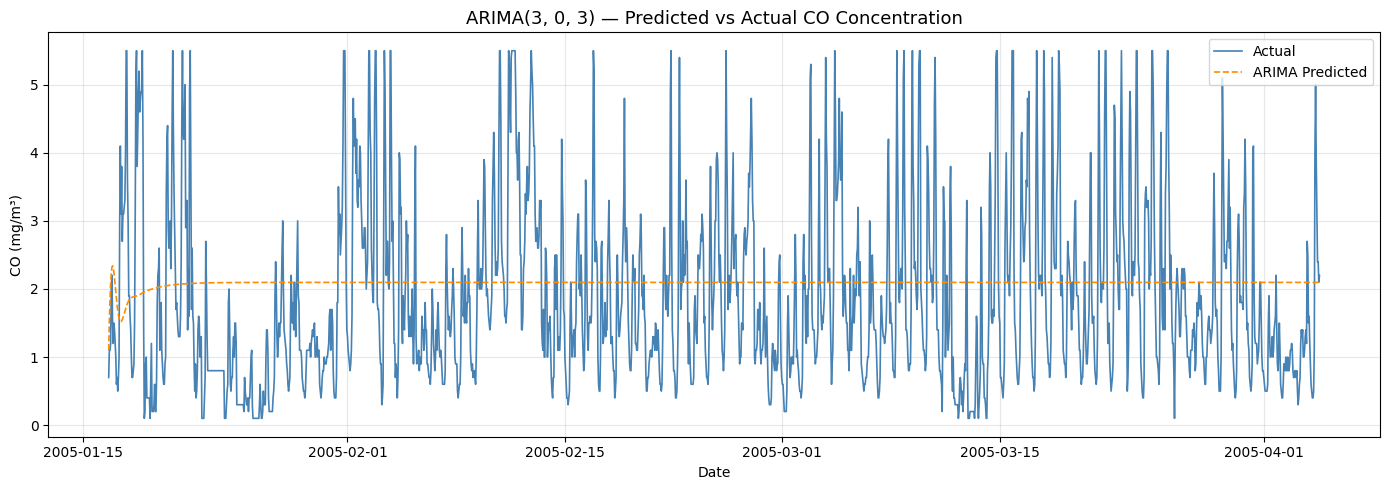

Plot saved as arima_predictions.png


In [187]:
plt.figure(figsize=(14, 5))

plt.plot(test_arima.index, test_arima.values,
         label='Actual', color='steelblue', linewidth=1.2)

plt.plot(forecast.index, forecast.values,
         label='ARIMA Predicted', color='darkorange',
         linewidth=1.2, linestyle='--')

plt.title(f'ARIMA{best_order} — Predicted vs Actual CO Concentration',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('CO (mg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_predictions.png', dpi=150)
plt.show()

print("Plot saved as arima_predictions.png")

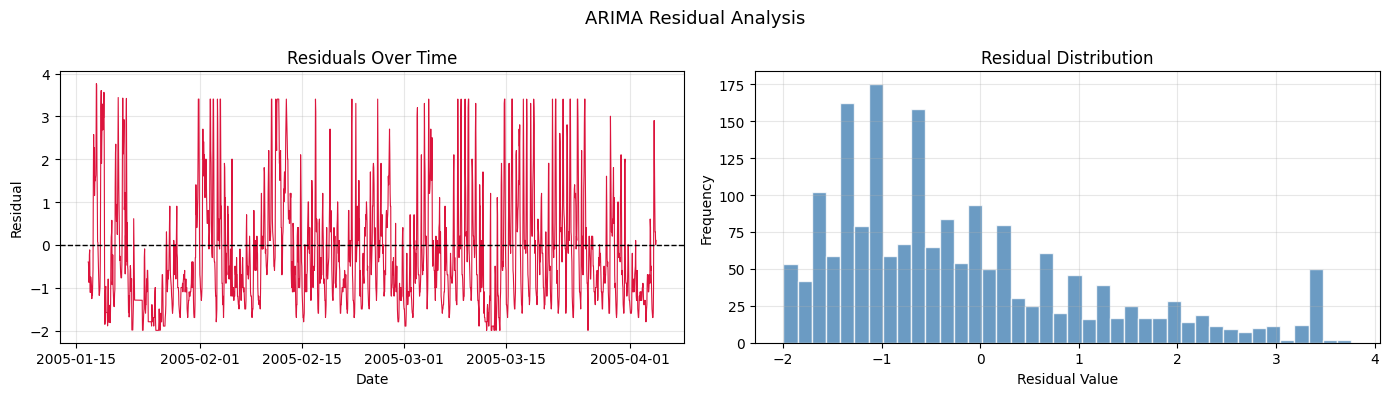

In [188]:
residuals = test_arima.values - forecast.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residual over time
axes[0].plot(test_arima.index, residuals,
             color='crimson', linewidth=0.8)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals Over Time', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[1].set_title('Residual Distribution', fontsize=12)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ARIMA Residual Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('arima_residuals.png', dpi=150)
plt.show()

In [189]:
import joblib

joblib.dump(arima_result,  'arima_model.pkl')
joblib.dump(arima_metrics, 'arima_metrics.pkl')
joblib.dump(forecast,      'arima_forecast.pkl')

print("ARIMA model and results saved successfully")

ARIMA model and results saved successfully


## 5. LSTM Modeling

A two-layer LSTM network with dropout regularization and early stopping, trained on 24-hour lookback sequences to capture non-linear temporal dependencies.


In [190]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import joblib

# Fix random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("All LSTM libraries imported successfully")

TensorFlow version: 2.20.0
All LSTM libraries imported successfully


In [191]:
# Load the sequences we prepared in Phase 3
X_train_seq = joblib.load('X_train_seq.pkl')
y_train_seq = joblib.load('y_train_seq.pkl')
X_test_seq  = joblib.load('X_test_seq.pkl')
y_test_seq  = joblib.load('y_test_seq.pkl')
scaler      = joblib.load('scaler.pkl')

print("Data loaded successfully")
print("=" * 40)
print(f"X_train shape : {X_train_seq.shape}")
print(f"y_train shape : {y_train_seq.shape}")
print(f"X_test shape  : {X_test_seq.shape}")
print(f"y_test shape  : {y_test_seq.shape}")

# Extract dimensions
n_timesteps = X_train_seq.shape[1]
n_features  = X_train_seq.shape[2]

print(f"\nLookback window : {n_timesteps} hours")
print(f"Input features  : {n_features}")

Data loaded successfully
X_train shape : (7442, 24, 10)
y_train shape : (7442,)
X_test shape  : (1843, 24, 10)
y_test shape  : (1843,)

Lookback window : 24 hours
Input features  : 10


In [192]:
model = Sequential([
    Input(shape=(n_timesteps, n_features)),

    # First LSTM layer — learns broad temporal patterns
    LSTM(128, return_sequences=True),
    Dropout(0.2),

    # Second LSTM layer — learns finer patterns
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Output layer — single value prediction
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile with Adam optimizer
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

# Print model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)

In [193]:
# Early stopping — stops training if validation loss
# does not improve for 10 consecutive epochs

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint — saves best model automatically
checkpoint = ModelCheckpoint(
    filepath='best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Callbacks defined:")
print("  - EarlyStopping  (patience=10)")
print("  - ModelCheckpoint (saves best model)")

Callbacks defined:
  - EarlyStopping  (patience=10)
  - ModelCheckpoint (saves best model)


In [194]:
print("Training LSTM model...")
print("This may take 5–15 minutes depending on your machine\n")

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete")
print(f"Total epochs run     : {len(history.history['loss'])}")
print(f"Best validation loss : {min(history.history['val_loss']):.6f}")

Training LSTM model...
This may take 5–15 minutes depending on your machine

Epoch 1/100
197/198 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0562 - mae: 0.1787
Epoch 1: val_loss improved from None to 0.03197, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 0.0440 - mae: 0.1588 - val_loss: 0.0320 - val_mae: 0.1312
Epoch 2/100
197/198 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0293 - mae: 0.1271
Epoch 2: val_loss improved from 0.03197 to 0.02158, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.0287 - mae: 0.1259 - val_loss: 0.0216 - val_mae: 0.1106
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0215 - mae: 0.1072
Epoch 3: val_loss improved from 0.02158 to 0.01516, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
198/198 ━━━━━━━━━━━

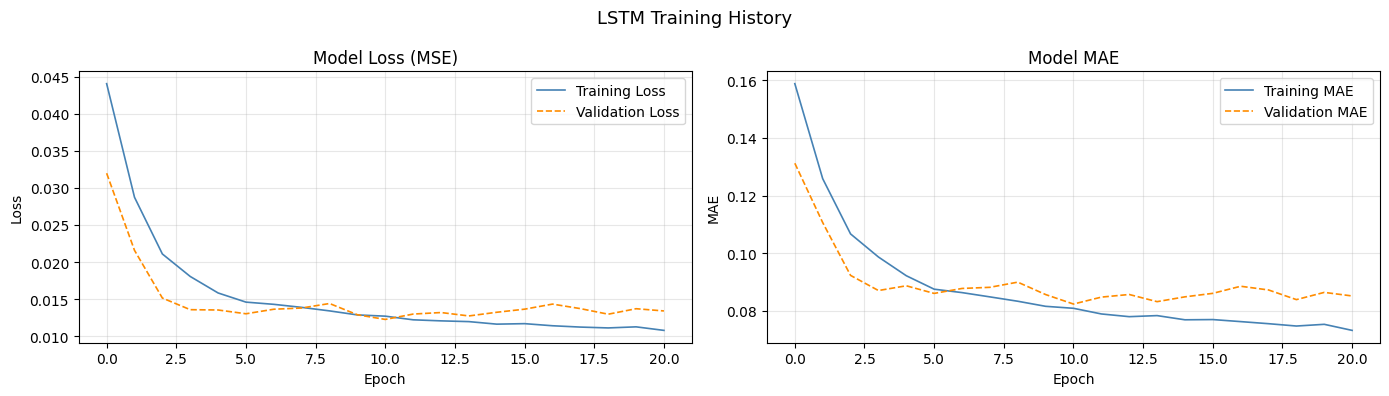

Training history plot saved as lstm_training_history.png


In [195]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(history.history['loss'],
             label='Training Loss', color='steelblue', linewidth=1.2)
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='darkorange',
             linewidth=1.2, linestyle='--')
axes[0].set_title('Model Loss (MSE)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE curve
axes[1].plot(history.history['mae'],
             label='Training MAE', color='steelblue', linewidth=1.2)
axes[1].plot(history.history['val_mae'],
             label='Validation MAE', color='darkorange',
             linewidth=1.2, linestyle='--')
axes[1].set_title('Model MAE', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

print("Training history plot saved as lstm_training_history.png")

In [196]:
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model('best_lstm_model.keras')

# Generate predictions on test set
y_pred_scaled = best_model.predict(X_test_seq)

print("Predictions generated")
print("Predicted shape:", y_pred_scaled.shape)

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Predictions generated
Predicted shape: (1843, 1)


In [197]:
# Our predictions are in scaled [0,1] range
# We need to convert back to original CO units (mg/m³)

# The scaler was fit on all features — we need to
# inverse transform only the target column (index 0)

n_features_total = scaler.n_features_in_

# Create dummy arrays to inverse transform just the target
def inverse_transform_target(scaler, values, target_index=0,
                              n_features=n_features_total):
    dummy = np.zeros((len(values), n_features))
    dummy[:, target_index] = values.flatten()
    inversed = scaler.inverse_transform(dummy)
    return inversed[:, target_index]

y_pred_actual = inverse_transform_target(scaler, y_pred_scaled)
y_test_actual = inverse_transform_target(scaler, y_test_seq)

print("Inverse transformation complete")
print(f"Sample predictions : {y_pred_actual[:5].round(4)}")
print(f"Sample actuals     : {y_test_actual[:5].round(4)}")

Inverse transformation complete
Sample predictions : [5.0642 3.226  2.3207 1.8219 1.6224]
Sample actuals     : [3.6 3.  1.9 1.9 1.6]


In [198]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) /
               (y_test_actual + 1e-10))) * 100
r2   = r2_score(y_test_actual, y_pred_actual)

print("=" * 40)
print("LSTM Model Evaluation Results")
print("=" * 40)
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"R²    : {r2:.4f}")
print("=" * 40)

lstm_metrics = {
    'Model' : 'LSTM',
    'RMSE'  : round(rmse, 4),
    'MAE'   : round(mae, 4),
    'MAPE'  : round(mape, 2),
    'R2'    : round(r2, 4)
}

print("\n✅ LSTM metrics saved for comparison")

LSTM Model Evaluation Results
RMSE  : 0.5913
MAE   : 0.4175
MAPE  : 37.69%
R²    : 0.7935

✅ LSTM metrics saved for comparison


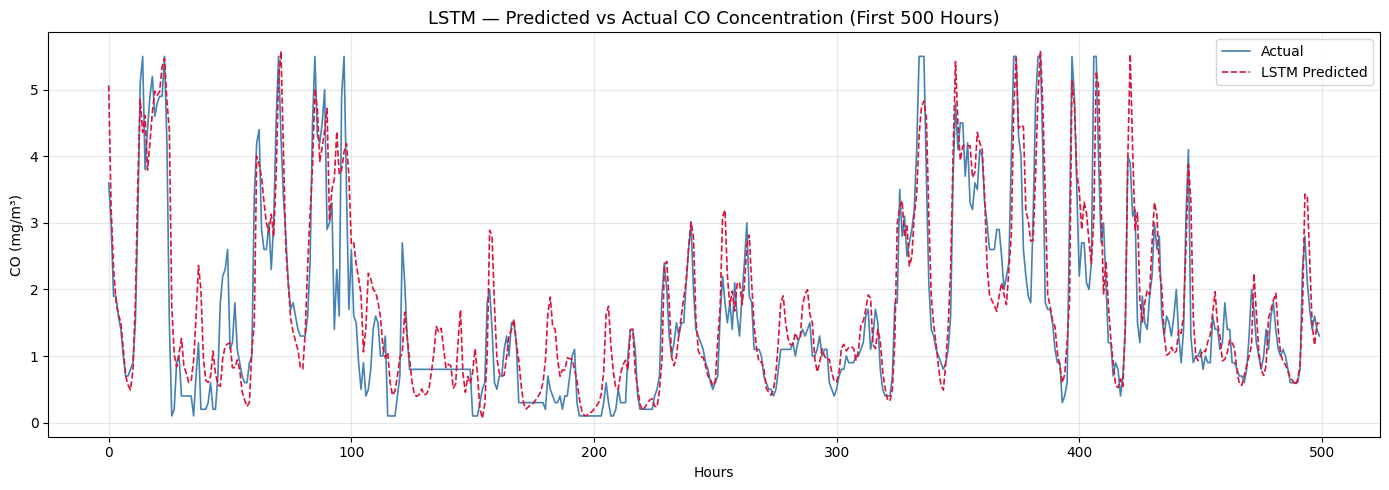

Plot saved as lstm_predictions.png


In [199]:
# Use last N points for a cleaner plot
plot_n = 500

plt.figure(figsize=(14, 5))

plt.plot(range(plot_n), y_test_actual[:plot_n],
         label='Actual', color='steelblue', linewidth=1.2)

plt.plot(range(plot_n), y_pred_actual[:plot_n],
         label='LSTM Predicted', color='crimson',
         linewidth=1.2, linestyle='--')

plt.title('LSTM — Predicted vs Actual CO Concentration (First 500 Hours)',
          fontsize=13)
plt.xlabel('Hours')
plt.ylabel('CO (mg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150)
plt.show()

print("Plot saved as lstm_predictions.png")

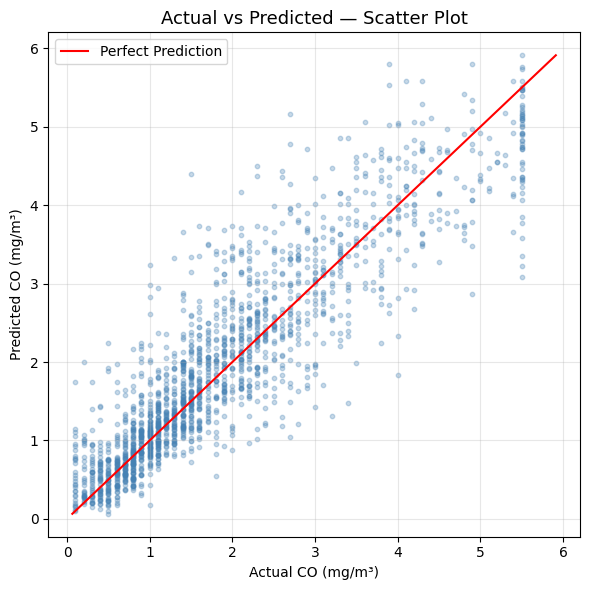

In [200]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test_actual, y_pred_actual,
            alpha=0.3, color='steelblue', s=10)

# Perfect prediction line
min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=1.5, label='Perfect Prediction')

plt.title('Actual vs Predicted — Scatter Plot', fontsize=13)
plt.xlabel('Actual CO (mg/m³)')
plt.ylabel('Predicted CO (mg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_scatter.png', dpi=150)
plt.show()

In [201]:
# Load ARIMA metrics saved in Phase 4
arima_metrics = joblib.load('arima_metrics.pkl')

# Build comparison table
comparison_df = pd.DataFrame([arima_metrics, lstm_metrics])
comparison_df = comparison_df.set_index('Model')

print("=" * 50)
print("Model Comparison — ARIMA vs LSTM")
print("=" * 50)
print(comparison_df.to_string())
print("=" * 50)

# Highlight winner
if lstm_metrics['RMSE'] < arima_metrics['RMSE']:
    print("\n✅ LSTM outperforms ARIMA on RMSE")
else:
    print("\n⚠️ ARIMA outperforms LSTM on RMSE")

Model Comparison — ARIMA vs LSTM
         RMSE     MAE    MAPE      R2
Model                                
ARIMA  1.3255  1.0877  138.39 -0.0338
LSTM   0.5913  0.4175   37.69  0.7935

✅ LSTM outperforms ARIMA on RMSE


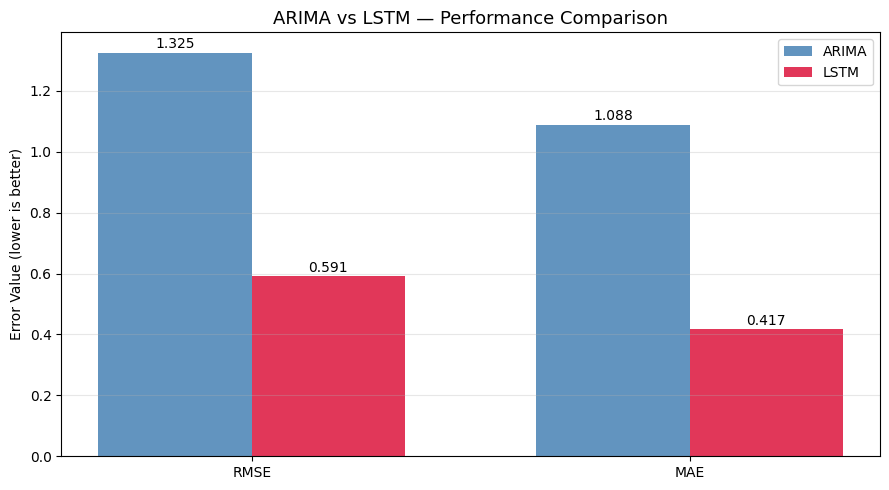

Comparison chart saved as model_comparison.png


In [202]:
metrics_to_plot = ['RMSE', 'MAE']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2,
               [arima_metrics['RMSE'], arima_metrics['MAE']],
               width, label='ARIMA', color='steelblue', alpha=0.85)

bars2 = ax.bar(x + width/2,
               [lstm_metrics['RMSE'], lstm_metrics['MAE']],
               width, label='LSTM', color='crimson', alpha=0.85)

ax.set_title('ARIMA vs LSTM — Performance Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Error Value (lower is better)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("Comparison chart saved as model_comparison.png")

In [203]:
joblib.dump(lstm_metrics,   'lstm_metrics.pkl')
joblib.dump(y_pred_actual,  'lstm_predictions.pkl')
joblib.dump(y_test_actual,  'lstm_actuals.pkl')
joblib.dump(comparison_df,  'model_comparison.pkl')

print("All LSTM results saved successfully")
print("\nFiles saved:")
print("  lstm_metrics.pkl")
print("  lstm_predictions.pkl")
print("  lstm_actuals.pkl")
print("  model_comparison.pkl")
print("  best_lstm_model.keras")

All LSTM results saved successfully

Files saved:
  lstm_metrics.pkl
  lstm_predictions.pkl
  lstm_actuals.pkl
  model_comparison.pkl
  best_lstm_model.keras


## 6. Association Rule Mining (Apriori)

Pollutant levels are discretized into Low/Medium/High categories per hour, combined with seasonal/time context, and mined for frequent itemsets and high-confidence association rules.


In [204]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("Apriori libraries imported successfully")

Apriori libraries imported successfully


In [205]:
# We work on the clean resampled data from Phase 3
# Use original unscaled values for interpretability

mining_df = data.copy()

print("Data loaded for pattern mining")
print("Shape:", mining_df.shape)
print("Columns:", mining_df.columns.tolist())
mining_df.head()

Data loaded for pattern mining
Shape: (9357, 7)
Columns: ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']


,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
Datetime,,,,,,,
2004-03-10 18:00:00,2.6,166.0,113.0,11.9,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,103.0,92.0,9.4,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,131.0,114.0,9.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,172.0,122.0,9.2,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,131.0,116.0,6.5,11.2,59.6,0.7888


In [206]:
# Add hour, day, and season columns
# These help discover time-based pollution patterns

mining_df['Hour']    = mining_df.index.hour
mining_df['DayName'] = mining_df.index.day_name()
mining_df['Month']   = mining_df.index.month

def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                     return 'Autumn'

def get_time_of_day(hour):
    if 6  <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:                  return 'Night'

mining_df['Season']    = mining_df['Month'].apply(get_season)
mining_df['TimeOfDay'] = mining_df['Hour'].apply(get_time_of_day)

print("Time features added:")
print(mining_df[['Hour', 'TimeOfDay', 'Season', 'DayName']].head(10))

Time features added:
                     Hour TimeOfDay  Season    DayName
Datetime                                              
2004-03-10 18:00:00    18   Evening  Spring  Wednesday
2004-03-10 19:00:00    19   Evening  Spring  Wednesday
2004-03-10 20:00:00    20   Evening  Spring  Wednesday
2004-03-10 21:00:00    21     Night  Spring  Wednesday
2004-03-10 22:00:00    22     Night  Spring  Wednesday
2004-03-10 23:00:00    23     Night  Spring  Wednesday
2004-03-11 00:00:00     0     Night  Spring   Thursday
2004-03-11 01:00:00     1     Night  Spring   Thursday
2004-03-11 02:00:00     2     Night  Spring   Thursday
2004-03-11 03:00:00     3     Night  Spring   Thursday


In [207]:
# Convert continuous pollutant values into
# categorical labels: Low / Medium / High
# This is required for Apriori (works on categories not numbers)

def categorise_pollutant(series, col_name):
    q33 = series.quantile(0.33)
    q66 = series.quantile(0.66)

    def label(val):
        if val <= q33:   return f'{col_name}_Low'
        elif val <= q66: return f'{col_name}_Medium'
        else:            return f'{col_name}_High'

    return series.apply(label)

# Apply to each pollutant column
pollutant_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']
pollutant_cols = [c for c in pollutant_cols if c in mining_df.columns]

for col in pollutant_cols:
    mining_df[f'{col}_cat'] = categorise_pollutant(mining_df[col], col)

print("Pollutant categories created:")
for col in pollutant_cols:
    print(f"\n{col} distribution:")
    print(mining_df[f'{col}_cat'].value_counts())

Pollutant categories created:

CO(GT) distribution:
CO(GT)_cat
CO(GT)_Low       3266
CO(GT)_Medium    3068
CO(GT)_High      3023
Name: count, dtype: int64

NOx(GT) distribution:
NOx(GT)_cat
NOx(GT)_High      3176
NOx(GT)_Low       3105
NOx(GT)_Medium    3076
Name: count, dtype: int64

NO2(GT) distribution:
NO2(GT)_cat
NO2(GT)_High      3155
NO2(GT)_Low       3115
NO2(GT)_Medium    3087
Name: count, dtype: int64

C6H6(GT) distribution:
C6H6(GT)_cat
C6H6(GT)_High      3151
C6H6(GT)_Low       3145
C6H6(GT)_Medium    3061
Name: count, dtype: int64


In [208]:
# Each row = one transaction (one hour observation)
# Each transaction contains category labels like:
# ['CO(GT)_High', 'NOx(GT)_High', 'TimeOfDay_Morning']

cat_cols = [f'{c}_cat' for c in pollutant_cols]

transactions = []

for _, row in mining_df.iterrows():
    transaction = []

    # Add pollutant category labels
    for col in cat_cols:
        transaction.append(row[col])

    # Add time context labels
    transaction.append(f"Time_{row['TimeOfDay']}")
    transaction.append(f"Season_{row['Season']}")

    transactions.append(transaction)

print(f"Total transactions : {len(transactions)}")
print(f"\nSample transaction :")
print(transactions[0])

Total transactions : 9357

Sample transaction :
['CO(GT)_High', 'NOx(GT)_Medium', 'NO2(GT)_Medium', 'C6H6(GT)_High', 'Time_Evening', 'Season_Spring']


In [209]:
# TransactionEncoder converts list of transactions
# into a binary one-hot encoded DataFrame

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", transaction_df.shape)
print("\nColumn names:")
print(transaction_df.columns.tolist())
transaction_df.head()

Transaction matrix shape: (9357, 20)

Column names:
['C6H6(GT)_High', 'C6H6(GT)_Low', 'C6H6(GT)_Medium', 'CO(GT)_High', 'CO(GT)_Low', 'CO(GT)_Medium', 'NO2(GT)_High', 'NO2(GT)_Low', 'NO2(GT)_Medium', 'NOx(GT)_High', 'NOx(GT)_Low', 'NOx(GT)_Medium', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Time_Afternoon', 'Time_Evening', 'Time_Morning', 'Time_Night']


,C6H6(GT)_High,C6H6(GT)_Low,C6H6(GT)_Medium,CO(GT)_High,CO(GT)_Low,CO(GT)_Medium,NO2(GT)_High,NO2(GT)_Low,NO2(GT)_Medium,NOx(GT)_High,NOx(GT)_Low,NOx(GT)_Medium,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Time_Afternoon,Time_Evening,Time_Morning,Time_Night
0,True,False,False,True,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False
1,False,False,True,False,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False
2,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False
3,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,False,True
4,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,False,True


In [210]:
# min_support = 0.1 means item set must appear
# in at least 10% of all transactions

print("Running Apriori algorithm...")
print("min_support = 0.10")

frequent_itemsets = apriori(
    transaction_df,
    min_support=0.10,
    use_colnames=True,
    max_len=3
)

# Add length column
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nFrequent itemsets found : {len(frequent_itemsets)}")
print("\nTop 15 frequent itemsets by support:")
print(frequent_itemsets.sort_values('support', ascending=False)
      .head(15).to_string(index=False))

Running Apriori algorithm...
min_support = 0.10

Frequent itemsets found : 87

Top 15 frequent itemsets by support:
 support                   itemsets  length
0.375120               (Time_Night)       1
0.349043               (CO(GT)_Low)       1
0.339425             (NOx(GT)_High)       1
0.337181             (NO2(GT)_High)       1
0.336753            (C6H6(GT)_High)       1
0.336112             (C6H6(GT)_Low)       1
0.332906              (NO2(GT)_Low)       1
0.331837              (NOx(GT)_Low)       1
0.329913           (NO2(GT)_Medium)       1
0.328738           (NOx(GT)_Medium)       1
0.327883            (CO(GT)_Medium)       1
0.327135          (C6H6(GT)_Medium)       1
0.323074              (CO(GT)_High)       1
0.299776            (Season_Spring)       1
0.265042 (NO2(GT)_Low, NOx(GT)_Low)       2


In [211]:
# min_confidence = 0.6 means the rule must be
# correct at least 60% of the time

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.60
)

# Add useful columns
rules['antecedents_str'] = rules['antecedents'].apply(
    lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(
    lambda x: ', '.join(list(x)))

# Sort by lift (most interesting rules first)
rules = rules.sort_values('lift', ascending=False)

print(f"Association rules generated : {len(rules)}")
print("\nTop 15 rules by lift:")
print(rules[['antecedents_str', 'consequents_str',
             'support', 'confidence', 'lift']]
      .head(15).to_string(index=False))

Association rules generated : 79

Top 15 rules by lift:
            antecedents_str         consequents_str  support  confidence     lift
 Season_Summer, NO2(GT)_Low             NOx(GT)_Low 0.117987    0.971831 2.928638
 Season_Autumn, CO(GT)_High            NOx(GT)_High 0.100780    0.978216 2.881979
NOx(GT)_High, C6H6(GT)_High             CO(GT)_High 0.188415    0.905496 2.802753
  C6H6(GT)_Low, NOx(GT)_Low             NO2(GT)_Low 0.182858    0.931410 2.797818
NO2(GT)_High, C6H6(GT)_High             CO(GT)_High 0.189698    0.899189 2.783234
                NO2(GT)_Low NOx(GT)_Low, CO(GT)_Low 0.206476    0.620225 2.770140
    NOx(GT)_Low, CO(GT)_Low             NO2(GT)_Low 0.206476    0.922196 2.770140
  C6H6(GT)_Low, NO2(GT)_Low             NOx(GT)_Low 0.182858    0.884238 2.664674
  C6H6(GT)_Low, NO2(GT)_Low              CO(GT)_Low 0.185850    0.898708 2.574774
    CO(GT)_Low, NO2(GT)_Low             NOx(GT)_Low 0.206476    0.841463 2.535772
                NOx(GT)_Low CO(GT)_Low, NO

In [212]:
# Focus on rules involving High pollution levels
# These are the most actionable for business decisions

high_rules = rules[
    rules['consequents_str'].str.contains('High')
].copy()

high_rules = high_rules.sort_values('confidence', ascending=False)

print("Rules predicting HIGH pollution levels:")
print(f"Total: {len(high_rules)}\n")
print(high_rules[['antecedents_str', 'consequents_str',
                   'support', 'confidence', 'lift']]
      .head(10).to_string(index=False))

Rules predicting HIGH pollution levels:
Total: 31

            antecedents_str consequents_str  support  confidence     lift
 Season_Autumn, CO(GT)_High    NOx(GT)_High 0.100780    0.978216 2.881979
NOx(GT)_High, C6H6(GT)_High     CO(GT)_High 0.188415    0.905496 2.802753
NO2(GT)_High, C6H6(GT)_High     CO(GT)_High 0.189698    0.899189 2.783234
Season_Winter, NOx(GT)_High    NO2(GT)_High 0.104628    0.845423 2.507329
  NO2(GT)_High, CO(GT)_High   C6H6(GT)_High 0.189698    0.832942 2.473450
                CO(GT)_High   C6H6(GT)_High 0.262157    0.811446 2.409615
  NOx(GT)_High, CO(GT)_High   C6H6(GT)_High 0.188415    0.811321 2.409244
  NO2(GT)_High, CO(GT)_High    NOx(GT)_High 0.183071    0.803848 2.368264
NO2(GT)_High, Season_Winter    NOx(GT)_High 0.104628    0.797231 2.348770
  NOx(GT)_High, CO(GT)_High    NO2(GT)_High 0.183071    0.788311 2.337948


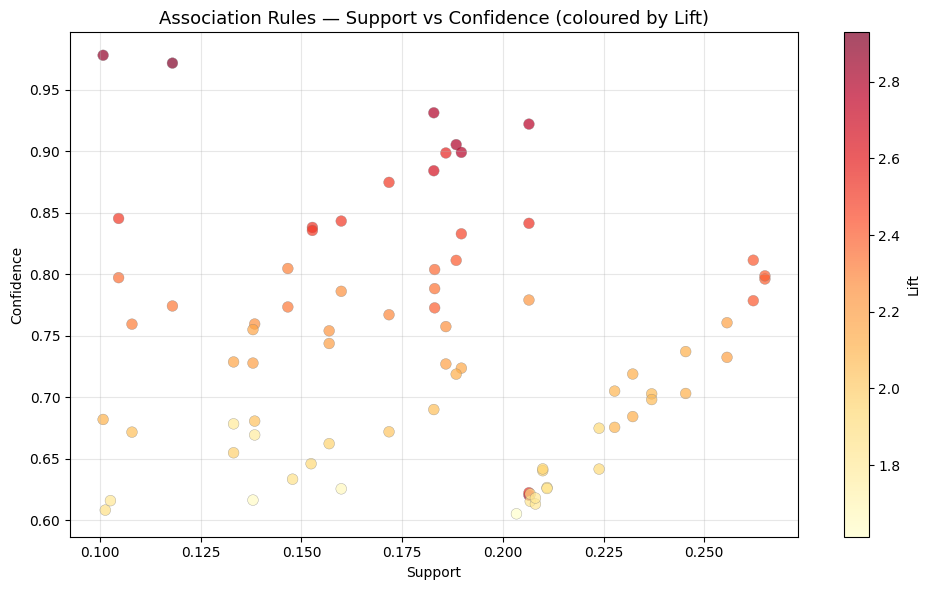

Plot saved as apriori_rules_scatter.png


In [213]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    s=60,
    alpha=0.7,
    edgecolors='grey',
    linewidth=0.3
)

plt.colorbar(scatter, label='Lift')
plt.title('Association Rules — Support vs Confidence (coloured by Lift)',
          fontsize=13)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('apriori_rules_scatter.png', dpi=150)
plt.show()

print("Plot saved as apriori_rules_scatter.png")

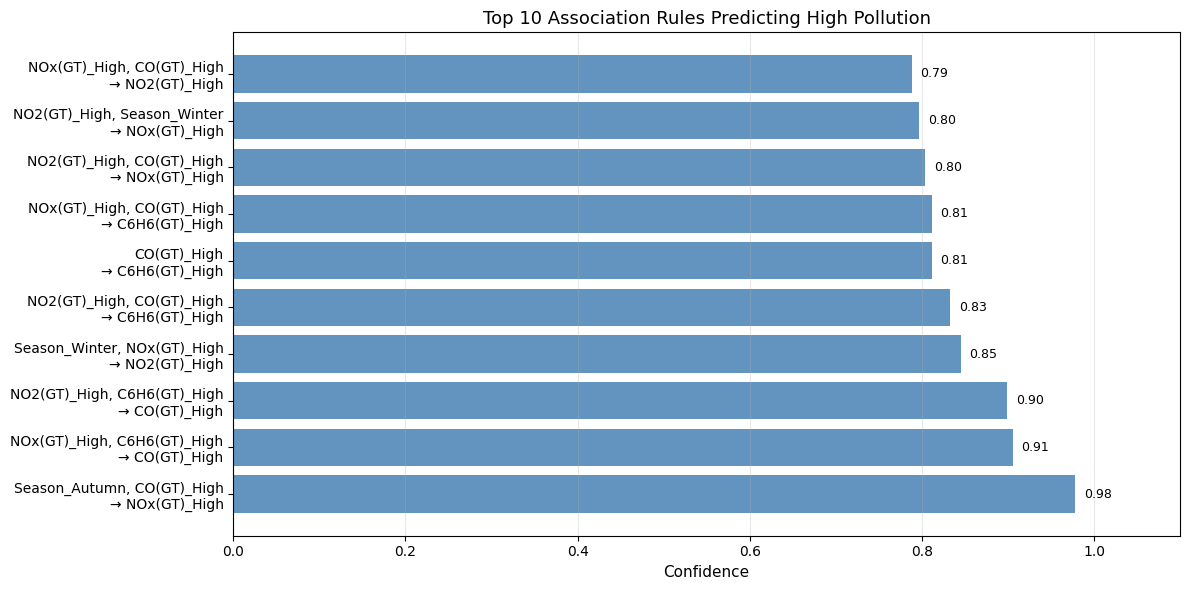

Plot saved as apriori_top_rules.png


In [214]:
top10 = high_rules.head(10).copy()
top10['rule'] = top10['antecedents_str'] + '\n→ ' + top10['consequents_str']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top10['rule'], top10['confidence'],
               color='steelblue', alpha=0.85)

ax.set_xlabel('Confidence', fontsize=11)
ax.set_title('Top 10 Association Rules Predicting High Pollution',
             fontsize=13)
ax.set_xlim(0, 1.1)
ax.grid(True, alpha=0.3, axis='x')

# Add confidence labels
for bar, val in zip(bars, top10['confidence']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('apriori_top_rules.png', dpi=150)
plt.show()

print("Plot saved as apriori_top_rules.png")

In [215]:
print("=" * 65)
print("HUMAN-READABLE RULE INTERPRETATIONS")
print("USE THESE DIRECTLY IN YOUR REPORT")
print("=" * 65)

for i, row in high_rules.head(8).iterrows():
    print(f"\nRule {i+1}:")
    print(f"  IF   : {row['antecedents_str']}")
    print(f"  THEN : {row['consequents_str']}")
    print(f"  Support    = {row['support']:.2f}  "
          f"(occurs in {row['support']*100:.1f}% of hours)")
    print(f"  Confidence = {row['confidence']:.2f}  "
          f"(true {row['confidence']*100:.1f}% of the time)")
    print(f"  Lift       = {row['lift']:.2f}  "
          f"({'stronger' if row['lift'] > 1 else 'weaker'} than random)")
    print("-" * 65)

HUMAN-READABLE RULE INTERPRETATIONS
USE THESE DIRECTLY IN YOUR REPORT

Rule 63:
  IF   : Season_Autumn, CO(GT)_High
  THEN : NOx(GT)_High
  Support    = 0.10  (occurs in 10.1% of hours)
  Confidence = 0.98  (true 97.8% of the time)
  Lift       = 2.88  (stronger than random)
-----------------------------------------------------------------

Rule 35:
  IF   : NOx(GT)_High, C6H6(GT)_High
  THEN : CO(GT)_High
  Support    = 0.19  (occurs in 18.8% of hours)
  Confidence = 0.91  (true 90.5% of the time)
  Lift       = 2.80  (stronger than random)
-----------------------------------------------------------------

Rule 32:
  IF   : NO2(GT)_High, C6H6(GT)_High
  THEN : CO(GT)_High
  Support    = 0.19  (occurs in 19.0% of hours)
  Confidence = 0.90  (true 89.9% of the time)
  Lift       = 2.78  (stronger than random)
-----------------------------------------------------------------

Rule 75:
  IF   : Season_Winter, NOx(GT)_High
  THEN : NO2(GT)_High
  Support    = 0.10  (occurs in 10.5% of hour

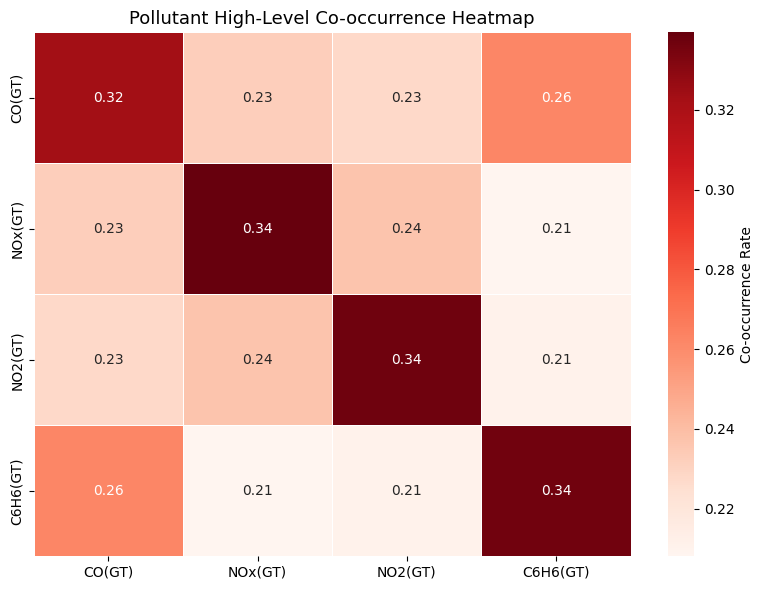

Heatmap saved as pollutant_cooccurrence.png


In [216]:
# Show how often High levels of different pollutants occur together

high_cols = [f'{c}_cat' for c in pollutant_cols]
high_matrix = pd.DataFrame(index=pollutant_cols, columns=pollutant_cols,
                             dtype=float)

for col1 in pollutant_cols:
    for col2 in pollutant_cols:
        both_high = (
            (mining_df[f'{col1}_cat'] == f'{col1}_High') &
            (mining_df[f'{col2}_cat'] == f'{col2}_High')
        ).sum()
        high_matrix.loc[col1, col2] = both_high / len(mining_df)

plt.figure(figsize=(8, 6))
sns.heatmap(high_matrix.astype(float),
            annot=True,
            fmt='.2f',
            cmap='Reds',
            linewidths=0.5,
            cbar_kws={'label': 'Co-occurrence Rate'})

plt.title('Pollutant High-Level Co-occurrence Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('pollutant_cooccurrence.png', dpi=150)
plt.show()

print("Heatmap saved as pollutant_cooccurrence.png")

In [217]:
joblib.dump(frequent_itemsets, 'frequent_itemsets.pkl')
joblib.dump(rules,             'association_rules.pkl')
joblib.dump(high_rules,        'high_pollution_rules.pkl')

rules.to_csv('association_rules.csv', index=False)
high_rules.to_csv('high_pollution_rules.csv', index=False)

print("All Apriori results saved:")
print("  frequent_itemsets.pkl")
print("  association_rules.pkl")
print("  high_pollution_rules.pkl")
print("  association_rules.csv")
print("  high_pollution_rules.csv")

All Apriori results saved:
  frequent_itemsets.pkl
  association_rules.pkl
  high_pollution_rules.pkl
  association_rules.csv
  high_pollution_rules.csv


## 7. Model Comparison & Summary Dashboard

Side-by-side comparison of ARIMA vs. LSTM performance, plus a consolidated dashboard of the project's key results.


In [218]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [219]:
# Load everything saved from previous phases
arima_metrics    = joblib.load('arima_metrics.pkl')
lstm_metrics     = joblib.load('lstm_metrics.pkl')
arima_forecast   = joblib.load('arima_forecast.pkl')
y_pred_actual    = joblib.load('lstm_predictions.pkl')
y_test_actual    = joblib.load('lstm_actuals.pkl')
rules            = joblib.load('association_rules.pkl')
high_rules       = joblib.load('high_pollution_rules.pkl')
frequent_itemsets = joblib.load('frequent_itemsets.pkl')

print("All results loaded successfully")
print("=" * 45)
print("ARIMA Metrics:", arima_metrics)
print("LSTM  Metrics:", lstm_metrics)
print(f"Total rules  : {len(rules)}")
print(f"High rules   : {len(high_rules)}")

All results loaded successfully
ARIMA Metrics: {'Model': 'ARIMA', 'RMSE': np.float64(1.3255), 'MAE': 1.0877, 'MAPE': np.float64(138.39), 'R2': -0.0338}
LSTM  Metrics: {'Model': 'LSTM', 'RMSE': np.float64(0.5913), 'MAE': 0.4175, 'MAPE': np.float64(37.69), 'R2': 0.7935}
Total rules  : 79
High rules   : 31


In [220]:
comparison_df = pd.DataFrame([arima_metrics, lstm_metrics])
comparison_df = comparison_df.set_index('Model')

# Add improvement column
comparison_df['Improvement %'] = round(
    (comparison_df.loc['ARIMA'] - comparison_df.loc['LSTM']) /
     comparison_df.loc['ARIMA'] * 100, 2
)

print("=" * 55)
print("FINAL MODEL COMPARISON TABLE")
print("COPY THIS INTO YOUR REPORT — RESULTS SECTION")
print("=" * 55)
print(comparison_df.to_string())
print("=" * 55)

# Winner summary
for metric in ['RMSE', 'MAE', 'MAPE']:
    winner = 'LSTM' if lstm_metrics[metric] < arima_metrics[metric] \
             else 'ARIMA'
    print(f"{metric:6s} winner : {winner}")

FINAL MODEL COMPARISON TABLE
COPY THIS INTO YOUR REPORT — RESULTS SECTION
         RMSE     MAE    MAPE      R2  Improvement %
Model                                               
ARIMA  1.3255  1.0877  138.39 -0.0338            NaN
LSTM   0.5913  0.4175   37.69  0.7935            NaN
RMSE   winner : LSTM
MAE    winner : LSTM
MAPE   winner : LSTM


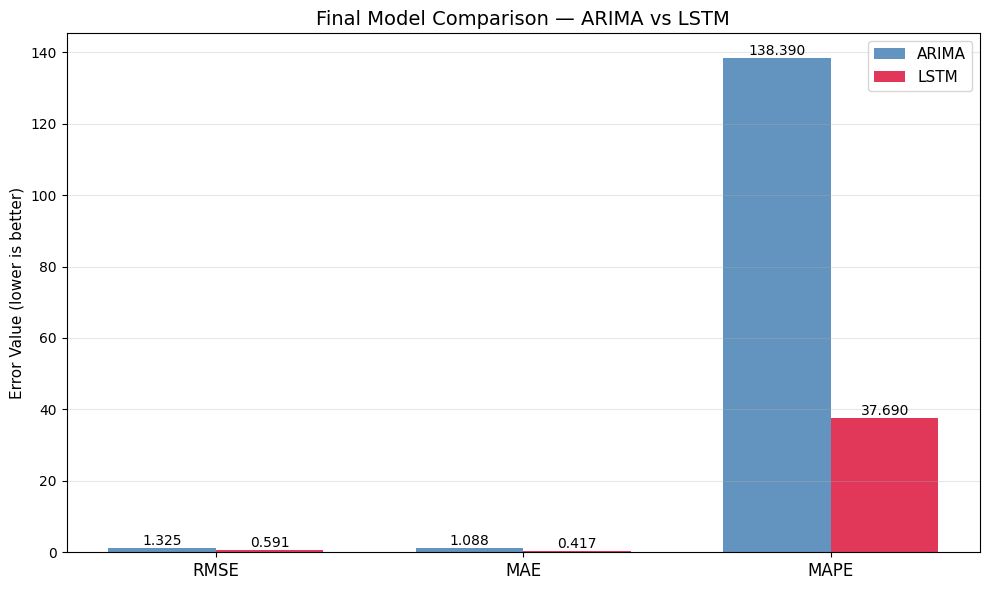

Saved as final_model_comparison.png


In [221]:
metrics   = ['RMSE', 'MAE', 'MAPE']
arima_vals = [arima_metrics[m] for m in metrics]
lstm_vals  = [lstm_metrics[m]  for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, arima_vals, width,
               label='ARIMA', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, lstm_vals,  width,
               label='LSTM',  color='crimson',   alpha=0.85)

ax.set_title('Final Model Comparison — ARIMA vs LSTM',  fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Error Value (lower is better)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

print("Saved as final_model_comparison.png")

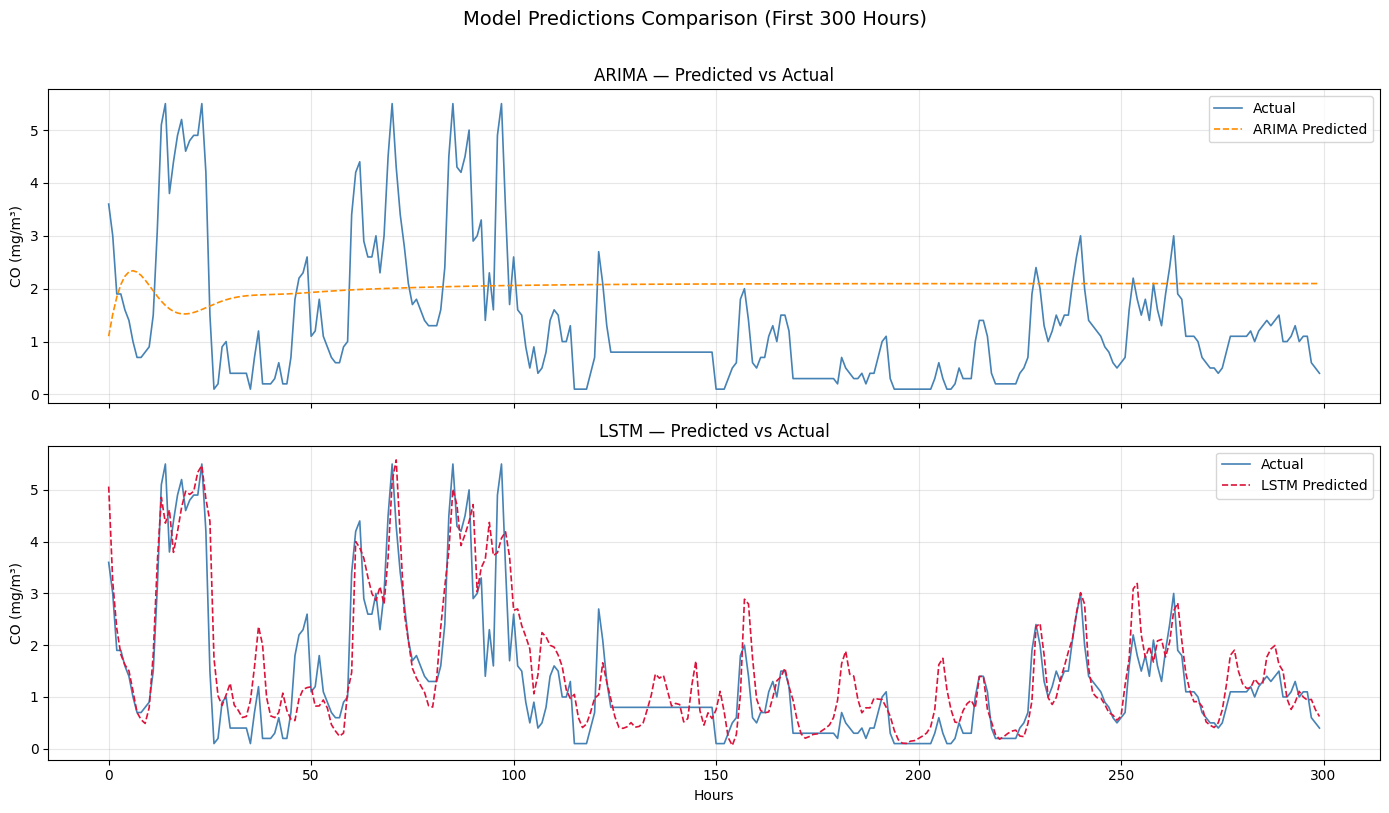

Saved as side_by_side_predictions.png


In [222]:
# Compare ARIMA and LSTM predictions on same chart
plot_n = 300

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ARIMA plot
arima_test_vals = arima_forecast.values[:plot_n]
axes[0].plot(range(plot_n), y_test_actual[:plot_n],
             label='Actual', color='steelblue', linewidth=1.2)
axes[0].plot(range(plot_n), arima_test_vals[:plot_n],
             label='ARIMA Predicted', color='darkorange',
             linewidth=1.2, linestyle='--')
axes[0].set_title('ARIMA — Predicted vs Actual', fontsize=12)
axes[0].set_ylabel('CO (mg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM plot
axes[1].plot(range(plot_n), y_test_actual[:plot_n],
             label='Actual', color='steelblue', linewidth=1.2)
axes[1].plot(range(plot_n), y_pred_actual[:plot_n],
             label='LSTM Predicted', color='crimson',
             linewidth=1.2, linestyle='--')
axes[1].set_title('LSTM — Predicted vs Actual', fontsize=12)
axes[1].set_ylabel('CO (mg/m³)')
axes[1].set_xlabel('Hours')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Predictions Comparison (First 300 Hours)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('side_by_side_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as side_by_side_predictions.png")

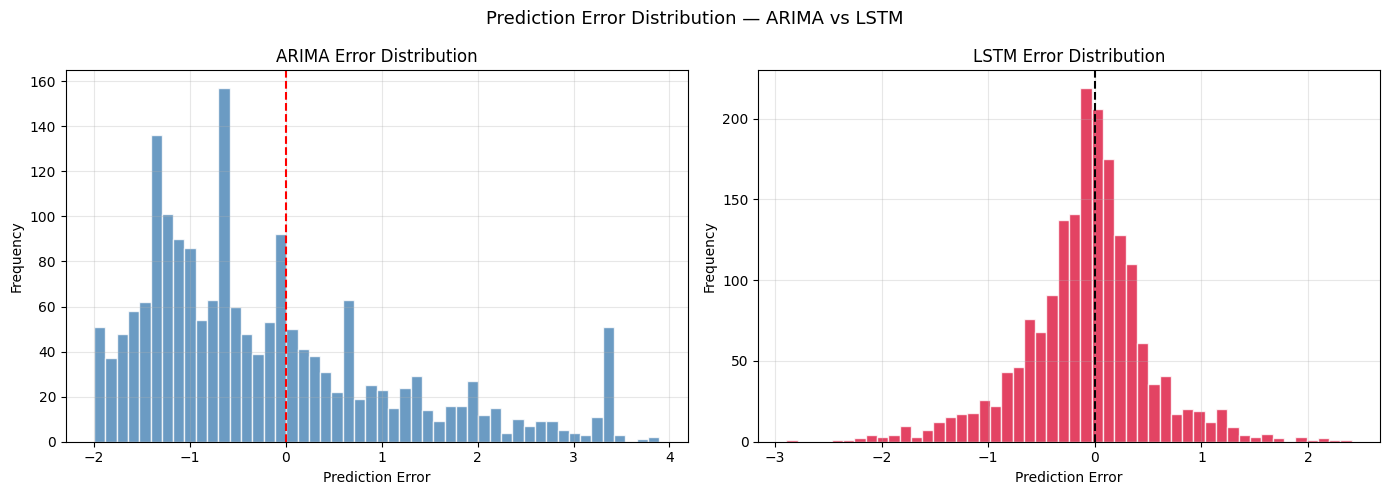

Saved as error_distribution.png


In [223]:
arima_errors = y_test_actual[:len(arima_forecast)] - \
               arima_forecast.values[:len(y_test_actual)]
lstm_errors  = y_test_actual - y_pred_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ARIMA error distribution
axes[0].hist(arima_errors, bins=50,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('ARIMA Error Distribution', fontsize=12)
axes[0].set_xlabel('Prediction Error')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# LSTM error distribution
axes[1].hist(lstm_errors, bins=50,
             color='crimson', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('LSTM Error Distribution', fontsize=12)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Prediction Error Distribution — ARIMA vs LSTM',
             fontsize=13)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150)
plt.show()

print("Saved as error_distribution.png")

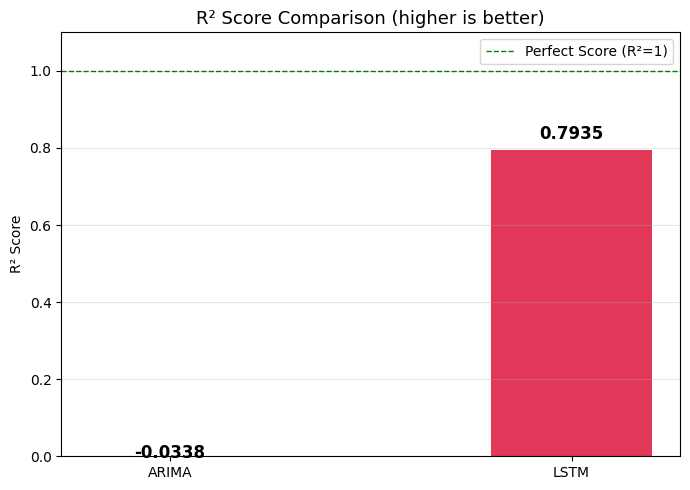

Saved as r2_comparison.png


In [224]:
fig, ax = plt.subplots(figsize=(7, 5))

models = ['ARIMA', 'LSTM']
r2_vals = [arima_metrics['R2'], lstm_metrics['R2']]
colors  = ['steelblue', 'crimson']

bars = ax.bar(models, r2_vals, color=colors, alpha=0.85, width=0.4)

ax.set_title('R² Score Comparison (higher is better)', fontsize=13)
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='green', linestyle='--',
           linewidth=1, label='Perfect Score (R²=1)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150)
plt.show()

print("Saved as r2_comparison.png")

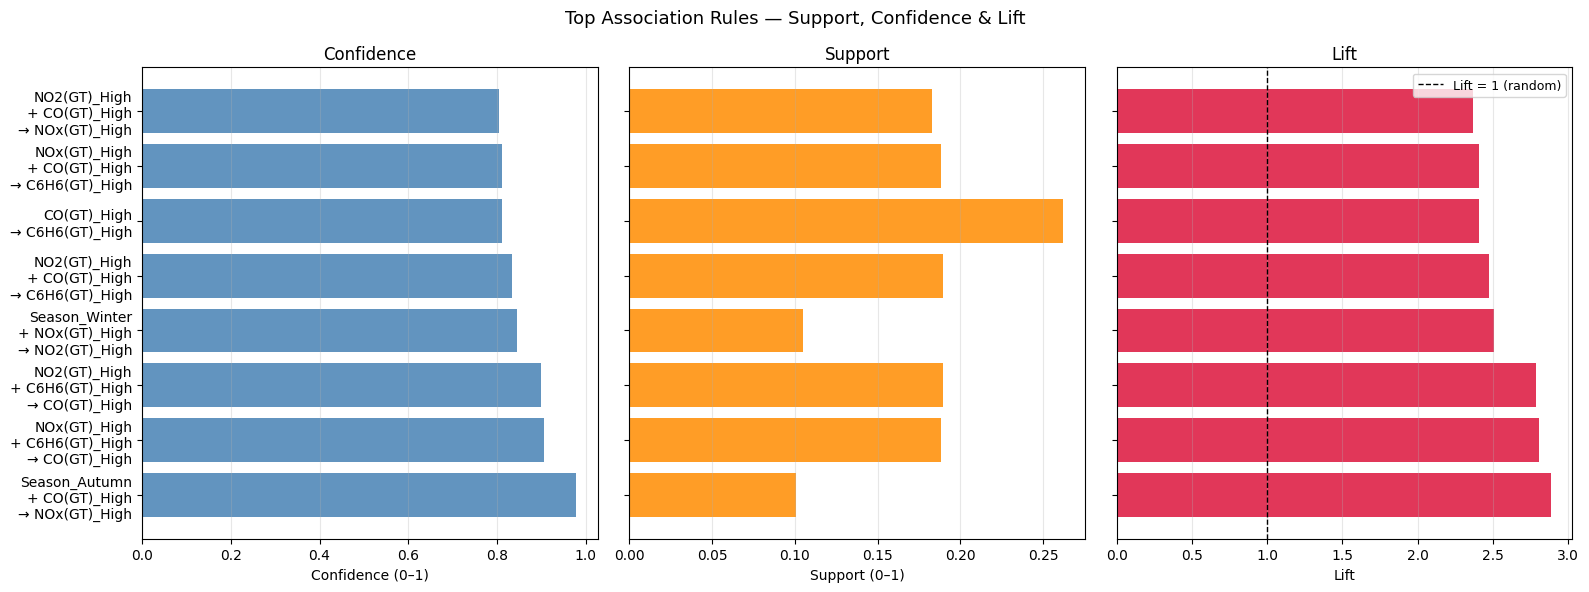

Saved as apriori_final_summary.png


In [225]:
top8 = high_rules.head(8).copy()
top8['rule_label'] = (top8['antecedents_str']
                      .str.replace(', ', '\n+ ') + '\n→ ' +
                      top8['consequents_str'])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Confidence
axes[0].barh(top8['rule_label'], top8['confidence'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Confidence', fontsize=12)
axes[0].set_xlabel('Confidence (0–1)')
axes[0].grid(True, alpha=0.3, axis='x')

# Support
axes[1].barh(top8['rule_label'], top8['support'],
             color='darkorange', alpha=0.85)
axes[1].set_title('Support', fontsize=12)
axes[1].set_xlabel('Support (0–1)')
axes[1].set_yticklabels([])
axes[1].grid(True, alpha=0.3, axis='x')

# Lift
axes[2].barh(top8['rule_label'], top8['lift'],
             color='crimson', alpha=0.85)
axes[2].axvline(x=1, color='black', linestyle='--',
                linewidth=1, label='Lift = 1 (random)')
axes[2].set_title('Lift', fontsize=12)
axes[2].set_xlabel('Lift')
axes[2].set_yticklabels([])
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Top Association Rules — Support, Confidence & Lift',
             fontsize=13)
plt.tight_layout()
plt.savefig('apriori_final_summary.png', dpi=150)
plt.show()

print("Saved as apriori_final_summary.png")

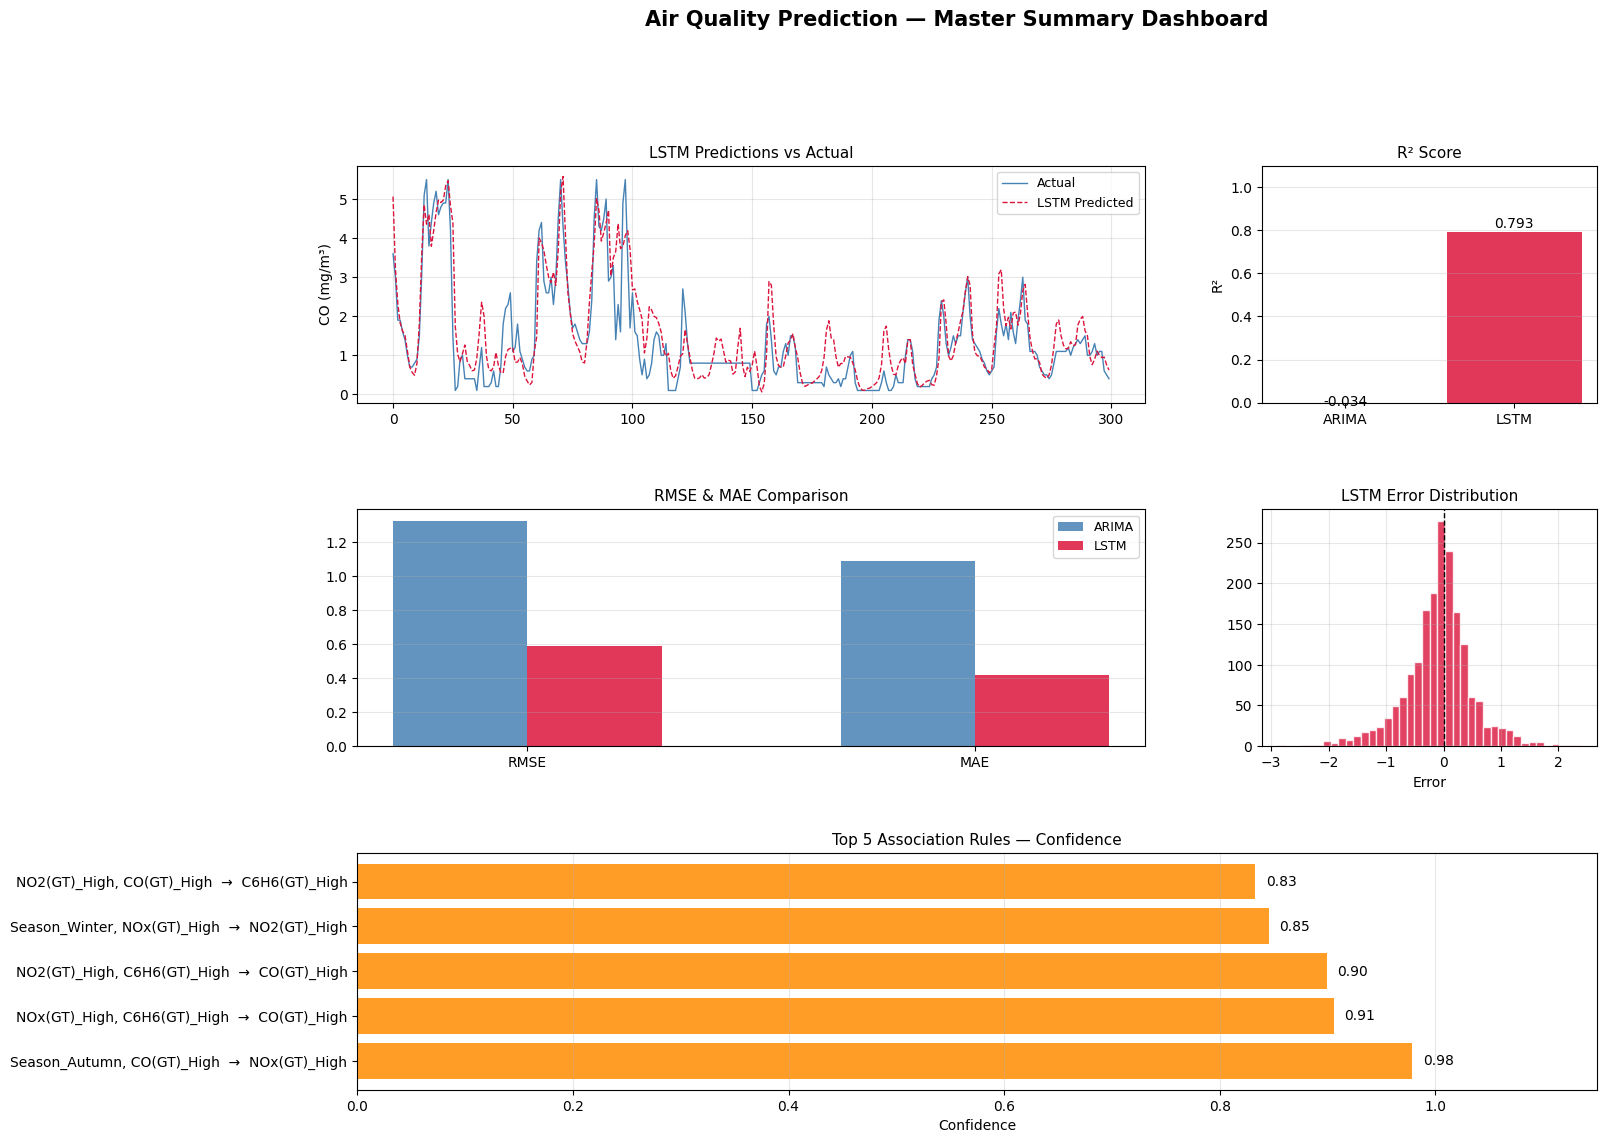

Master dashboard saved as master_dashboard.png


In [226]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: LSTM Predictions ---
ax1 = fig.add_subplot(gs[0, :2])
plot_n = 300
ax1.plot(range(plot_n), y_test_actual[:plot_n],
         label='Actual', color='steelblue', linewidth=1)
ax1.plot(range(plot_n), y_pred_actual[:plot_n],
         label='LSTM Predicted', color='crimson',
         linewidth=1, linestyle='--')
ax1.set_title('LSTM Predictions vs Actual', fontsize=11)
ax1.set_ylabel('CO (mg/m³)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: R² Comparison ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(['ARIMA', 'LSTM'],
        [arima_metrics['R2'], lstm_metrics['R2']],
        color=['steelblue', 'crimson'], alpha=0.85)
ax2.set_title('R² Score', fontsize=11)
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([arima_metrics['R2'], lstm_metrics['R2']]):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# --- Plot 3: RMSE & MAE Comparison ---
ax3 = fig.add_subplot(gs[1, :2])
x = np.arange(2)
w = 0.3
ax3.bar(x - w/2, [arima_metrics['RMSE'], arima_metrics['MAE']],
        w, label='ARIMA', color='steelblue', alpha=0.85)
ax3.bar(x + w/2, [lstm_metrics['RMSE'],  lstm_metrics['MAE']],
        w, label='LSTM',  color='crimson',   alpha=0.85)
ax3.set_title('RMSE & MAE Comparison', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(['RMSE', 'MAE'])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# --- Plot 4: LSTM Error Distribution ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(lstm_errors, bins=40, color='crimson',
         edgecolor='white', alpha=0.8)
ax4.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax4.set_title('LSTM Error Distribution', fontsize=11)
ax4.set_xlabel('Error')
ax4.grid(True, alpha=0.3)

# --- Plot 5: Top Rules Confidence ---
ax5 = fig.add_subplot(gs[2, :])
top5 = high_rules.head(5).copy()
top5['label'] = (top5['antecedents_str'] + '  →  ' +
                 top5['consequents_str'])
bars = ax5.barh(top5['label'], top5['confidence'],
                color='darkorange', alpha=0.85)
ax5.set_title('Top 5 Association Rules — Confidence',
              fontsize=11)
ax5.set_xlabel('Confidence')
ax5.set_xlim(0, 1.15)
for bar, val in zip(bars, top5['confidence']):
    ax5.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)
ax5.grid(True, alpha=0.3, axis='x')

plt.suptitle('Air Quality Prediction — Master Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('master_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Master dashboard saved as master_dashboard.png")

In [227]:
print("=" * 60)
print("   COMPLETE PROJECT RESULTS SUMMARY")
print("=" * 60)

print("\n📊 DATASET")
print(f"   Source      : UCI Air Quality Dataset")
print(f"   Target      : CO(GT) — Carbon Monoxide")
print(f"   Train/Test  : 80% / 20% (chronological split)")

print("\n📈 MODEL PERFORMANCE")
print(f"{'Metric':<10} {'ARIMA':>10} {'LSTM':>10} {'Winner':>10}")
print("-" * 45)
for m in ['RMSE', 'MAE', 'MAPE', 'R2']:
    a_val  = arima_metrics[m]
    l_val  = lstm_metrics[m]
    winner = 'LSTM' if l_val < a_val else 'ARIMA'
    if m == 'R2':
        winner = 'LSTM' if l_val > a_val else 'ARIMA'
    print(f"{m:<10} {a_val:>10.4f} {l_val:>10.4f} {winner:>10}")

print("\n🔍 PATTERN MINING (APRIORI)")
print(f"   Frequent itemsets : {len(frequent_itemsets)}")
print(f"   Association rules : {len(rules)}")
print(f"   High-risk rules   : {len(high_rules)}")
if len(high_rules) > 0:
    best = high_rules.iloc[0]
    print(f"\n   Best rule:")
    print(f"   IF   {best['antecedents_str']}")
    print(f"   THEN {best['consequents_str']}")
    print(f"   Confidence = {best['confidence']:.2f}, "
          f"Lift = {best['lift']:.2f}")

print("\n" + "=" * 60)
print("   PROJECT COMPLETE — READY TO WRITE REPORT")
print("=" * 60)

   COMPLETE PROJECT RESULTS SUMMARY
   COPY THIS INTO YOUR REPORT

📊 DATASET
   Source      : UCI Air Quality Dataset
   Target      : CO(GT) — Carbon Monoxide
   Train/Test  : 80% / 20% (chronological split)

📈 MODEL PERFORMANCE
Metric          ARIMA       LSTM     Winner
---------------------------------------------
RMSE           1.3255     0.5913       LSTM
MAE            1.0877     0.4175       LSTM
MAPE         138.3900    37.6900       LSTM
R2            -0.0338     0.7935       LSTM

🔍 PATTERN MINING (APRIORI)
   Frequent itemsets : 87
   Association rules : 79
   High-risk rules   : 31

   Best rule:
   IF   Season_Autumn, CO(GT)_High
   THEN NOx(GT)_High
   Confidence = 0.98, Lift = 2.88

   PROJECT COMPLETE — READY TO WRITE REPORT


In [228]:
summary = {
    'arima_metrics'    : arima_metrics,
    'lstm_metrics'     : lstm_metrics,
    'total_rules'      : len(rules),
    'high_risk_rules'  : len(high_rules),
    'frequent_itemsets': len(frequent_itemsets)
}

joblib.dump(summary, 'project_summary.pkl')
print("Final summary saved as project_summary.pkl")

Final summary saved as project_summary.pkl
